Install Required Libraries

In [1]:
pip install pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


Import Required Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load the Titanic Dataset

In [3]:
df = pd.read_csv("Dataset/titanic.csv")

Preview the Dataset

In [4]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None


Check Missing Values

In [6]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Handle Missing Values (Data Cleaning)

In [7]:
# Fill missing Age values with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing Embarked values with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])


In [8]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Question 1 – Who Survived More (Male or Female)

In [9]:
survival_gender = df.groupby('sex')['survived'].mean()
print(survival_gender)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


Visualization – Survival by Gender

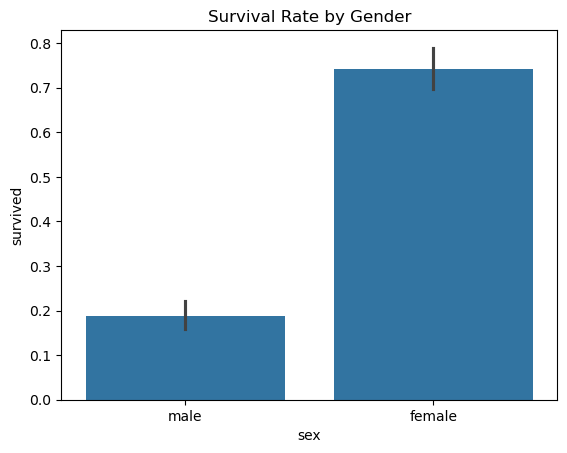

In [10]:
sns.barplot(x='sex', y='survived', data=df)

plt.title("Survival Rate by Gender")
plt.show()

Question 2 – Did Passenger Class Affect Survival

In [11]:
survival_class = df.groupby('pclass')['survived'].mean()
print(survival_class)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


Visualization – Survival by Passenger Class

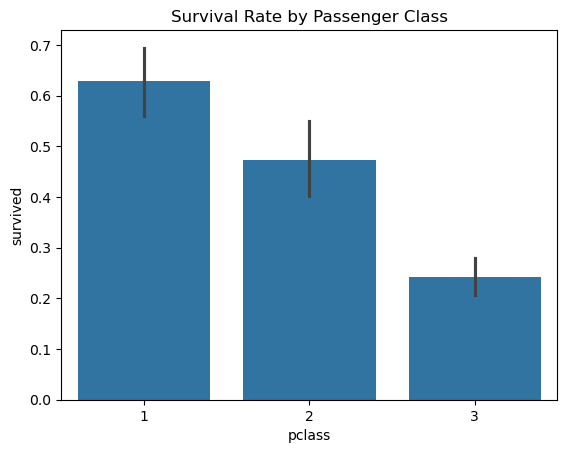

In [12]:
sns.barplot(x='pclass', y='survived', data=df)

plt.title("Survival Rate by Passenger Class")
plt.show()

In [13]:
df['AgeGroup'] = pd.cut(df['age'],
                        bins=[0,12,18,35,60,100],
                        labels=['Child','Teen','Young Adult','Adult','Senior'])

Question 3 – Survival Rate by Age Group

In [14]:
age_survival = df.groupby('AgeGroup')['survived'].mean()
print(age_survival)

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: survived, dtype: float64


C:\Users\Bhumika Patil\AppData\Local\Temp\ipykernel_13444\1472515.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['survived'].mean()


Visualization – Age Distribution

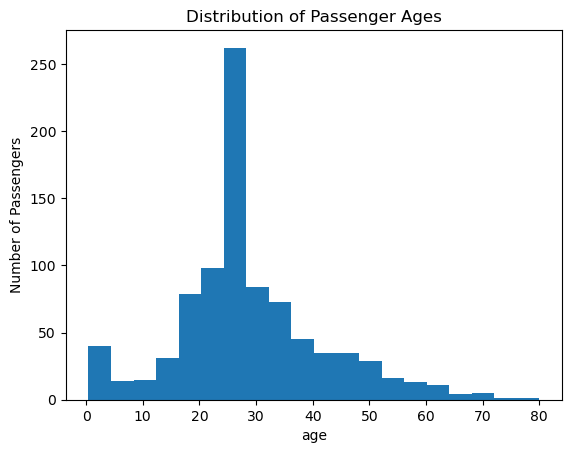

In [15]:
plt.hist(df['age'], bins=20)

plt.title("Distribution of Passenger Ages")
plt.xlabel("age")
plt.ylabel("Number of Passengers")

plt.show()

Visualization – Survival by Age Group

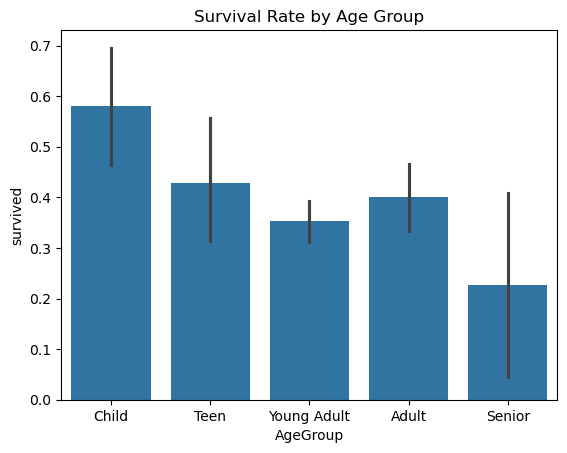

In [16]:
sns.barplot(x='AgeGroup', y='survived', data=df)

plt.title("Survival Rate by Age Group")
plt.show()

In [17]:
print("Females had higher survival rates than males.")
print("1st class passengers survived more than lower classes.")
print("Children had better survival chances compared to adults.")

Females had higher survival rates than males.
1st class passengers survived more than lower classes.
Children had better survival chances compared to adults.
